## Tensorflow Image Classifier

<i>

<br>

### Summary:

This notebook uses `tensorflow` to classify the images of cardboard cutouts which have different figures on them:

* bear
* fox
* reindeer
* santa
* cyclist
* robot

This exercises satisfies Module 3, part 1 of the Cloud-Based Machine Learning course. 

The model itself uses `MobileNetV2` as the backbone and uses the `ImageNet` pre-trained weights. It uses only a single classifier layer (because of the lack of pictures I placed into it.)

<br>
<br>

This notebook was ran using my WindowsPC using a WSL Ubuntu (22.04) instance running on `tensorflow`.

<br>
<br>

<strong> 

Total pictures used for the model: 

`428` </strong>.jpg images

<br>


---

### Code:




#### Imports

In [ ]:
# Imports
import tensorflow as tf
import matplotlib.pyplot as plt

# Ignore warnings
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

#### Loading Datasets

<i>

Here, we define the three dataset splits: train, test, and validation. We set the image_size to 224 because `MobileNetV2` expects it in that form. 


<strong><h5> Note: </strong></h5> 

These images have already been shuffled in the notebook: 04_img_shuffler.ipynb.

In [ ]:
# Loading Datasets

# Train Dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
"/mnt/c/Users/kykis/cloud_in_ml_portfolio/datasets/split/cardboard_images/train",
image_size = (224,224),
batch_size = 32
)

# Test Dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
"/mnt/c/Users/kykis/cloud_in_ml_portfolio/datasets/split/cardboard/images/test",
    image_size = (224,224),
    batch_size = 32
)

# Validation Dataset 
valid_ds = tf.keras.utils.image_dataset_from_directory(
"/mnt/c/Users/kykis/cloud_in_ml_portfolio/datasets/split/cardboard/images/val",
    image_size = (224,224),
    batch_size = 32, 
)

Found 296 files belonging to 7 classes.
Found 47 files belonging to 7 classes.
Found 85 files belonging to 7 classes.


#### Data Augmentation

<i>

Data Augmentation here is useful since we only have a limited amount of images to work with.
I've kept it fairly simple and not terribly aggressive. I might consider playing around with this later.

In [ ]:
'''
This part replates the images and alters them slightly.

It does the following: 

* Randomly flips them in a direction
* Rotates the images randomly
* Zooms in and out a little randomly
* Gives different contrasts at random intensities

We call this later when we define the model. 
'''

# Data augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
])


#### Compiling

<i>

Here is where we trained the dataset. I added a lot of comments and notes, mostly for myself because all of this is rather new.


In [ ]:
'''
This section uses the MobileNetV2 backbone. We chose this because it's lightweight and
not overly complex, which reduces the chance of overfitting.

- input_shape = (224, 224). Why? Because MobileNetV2 expects it.

- include_top = False. Why? Because by default, MobileNetV2 expects 1000 ImageNet Classes.
                now, we can put our own trained classifier on top, while using their 
                backbone and pre-trained weights.

- weights='imagenet'. Why? Because we're transfer learning. It uses 14 million images already.
                that helps figure out some basic patterns already. 
'''

# Pretrained backbone
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

'''
base_model.trainable = False. What does this mean?

It freezes all the imagenet's pretrained weights on TOP of our
classifier. Handy! (We could experiment with this a little later)
'''
base_model.trainable = False 


'''
Most of this is familiar to use, but there's some exceptions:
tf.keras.layers.Dropout(0.5): Why? Seems a bit aggressive.

Since we have a small dataset, we need to be aggressive anyways to reduce features, or
it will overfit. Additionally, we already have some pre-trained weights so we can afford to do that.. maybe!
'''
# Build the model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),
    data_augmentation,
    tf.keras.layers.Rescaling(1./255),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(9, activation='softmax')
])


'''
optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), why? 

Here, we're using adam for adaptive learning, and it works very well out of the box. Different optimizers 
have different compatible learning rates. 0.001 made sure it didn't overfit. We could probably get away with 
a little more, but I've spent 10 hours on optimization already. I have to move on. 
'''
# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Giving a summary of the dimensionality.
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_13 (Sequential)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_7 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 9)              │        11,529 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,269,513 (8.66 MB)

 Trainable params: 11,529 (45.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

#### Training and Crossvalidation

<i> 

Here, we train the model and check for overfitting with the validation accuracy metric. We're mostly interested in a high `val_accuracy` metric here.

In [ ]:
# Fitting the model to the validation dataset, to check for overfitting.
history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=20
)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 796ms/step - accuracy: 0.2466 - loss: 2.4291 - val_accuracy: 0.6118 - val_loss: 1.2260
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 660ms/step - accuracy: 0.4730 - loss: 1.3755 - val_accuracy: 0.7882 - val_loss: 0.7354
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 679ms/step - accuracy: 0.7466 - loss: 0.7577 - val_accuracy: 0.8118 - val_loss: 0.5590
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 769ms/step - accuracy: 0.7939 - loss: 0.6492 - val_accuracy: 0.8824 - val_loss: 0.4169
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 692ms/step - accuracy: 0.8885 - loss: 0.3886 - val_accuracy: 0.9059 - val_loss: 0.3542
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 688ms/step - accuracy: 0.8682 - loss: 0.3978 - val_accuracy: 0.9294 - val_loss: 0.3075
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 683ms/step - accuracy: 0.9223 - loss: 0.2679 - val_accuracy: 0.9412 - val_loss: 0.2408
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 665ms/step - accuracy: 0.9426 - loss: 0.2051 - val_accuracy: 0

---

### Visualizing the train vs. validation accuracy.

<i>

And to show our work, lets add a neat visual that shows the model is working mostly as intended.

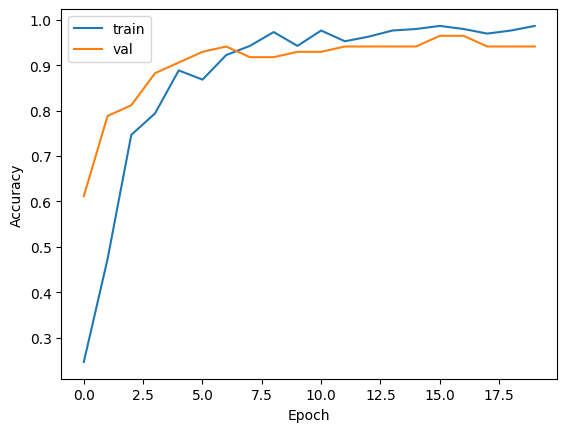

In [64]:
# Showing the 
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()